# Customer Purchasing Behavior: Data Preprocessing

This notebook covers the initial data preprocessing steps for the Customer Purchasing Behaviors dataset. The goal is to clean and prepare the data for clustering and predictive modeling.

The preprocessing workflow includes:
1.  **Loading the Data**: Import the dataset from `data/raw/`.
2.  **Handling Missing Values**: Identify and impute any missing data.
3.  **Handling Outliers**: Detect and cap outliers in numerical columns.
4.  **Encoding Categorical Features**: Convert the `region` column into a numerical format.
5.  **Standardizing Numerical Variables**: Scale numerical features to prepare them for clustering algorithms.

### 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set plot style
sns.set_style('whitegrid')

# Load the dataset
# The notebook is in the 'notebooks' directory, so we use a relative path.
file_path = '../data/raw/Customer Purchasing Behaviors.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


### 2. Initial Data Exploration

First, let's get a quick overview of the dataset to check for missing values and data types.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


The output from `df.info()` shows no missing values in any of the columns. All columns have 238 non-null entries. Therefore, we can skip the missing value imputation step.

### 3. Handle Outliers

Outliers can skew clustering algorithms. We will use box plots to visualize outliers in the numerical columns and then cap them using the Interquartile Range (IQR) method.

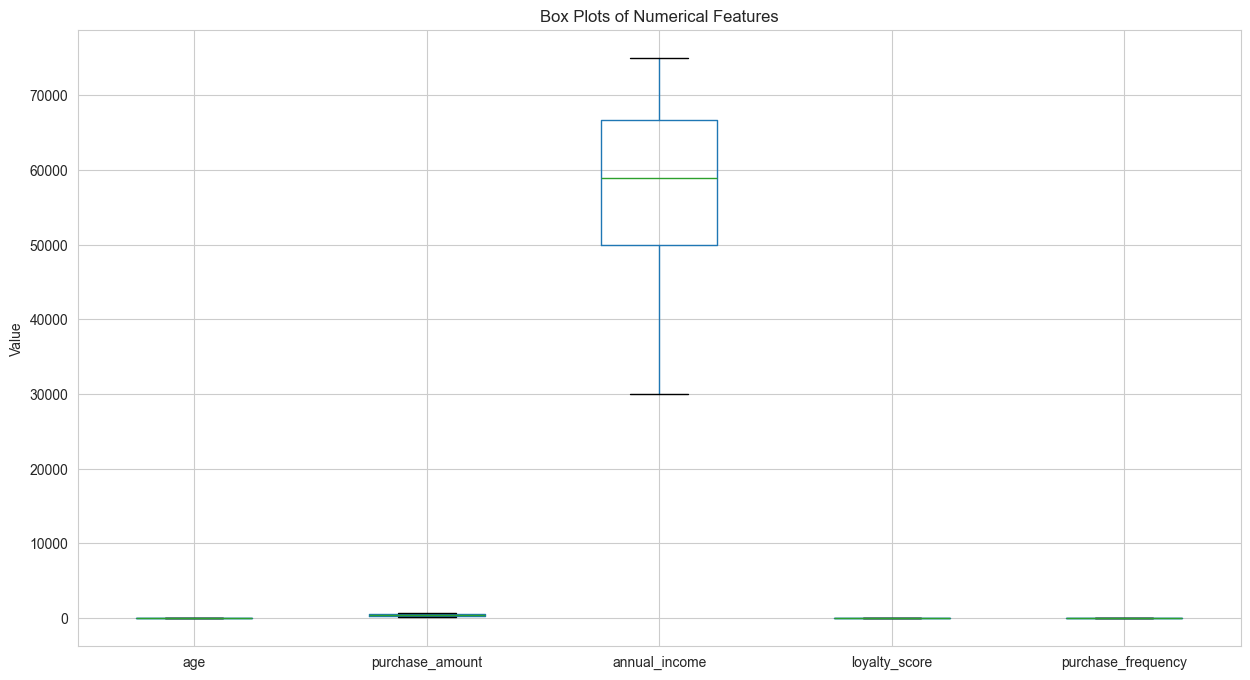

In [3]:
# Identify numerical columns (excluding ID columns)
numerical_cols = ['age', 'purchase_amount', 'annual_income', 'loyalty_score', 'purchase_frequency']

# Create box plots to visualize outliers
plt.figure(figsize=(15, 8))
df[numerical_cols].boxplot()
plt.title('Box Plots of Numerical Features')
plt.ylabel('Value')
plt.show()

The box plots indicate the presence of outliers, especially in `annual_income` and `loyalty_score`.

We will now cap these outliers. Any value above `Q3 + 1.5 * IQR` will be replaced by the upper bound, and any value below `Q1 - 1.5 * IQR` will be replaced by the lower bound.

Outliers have been capped.


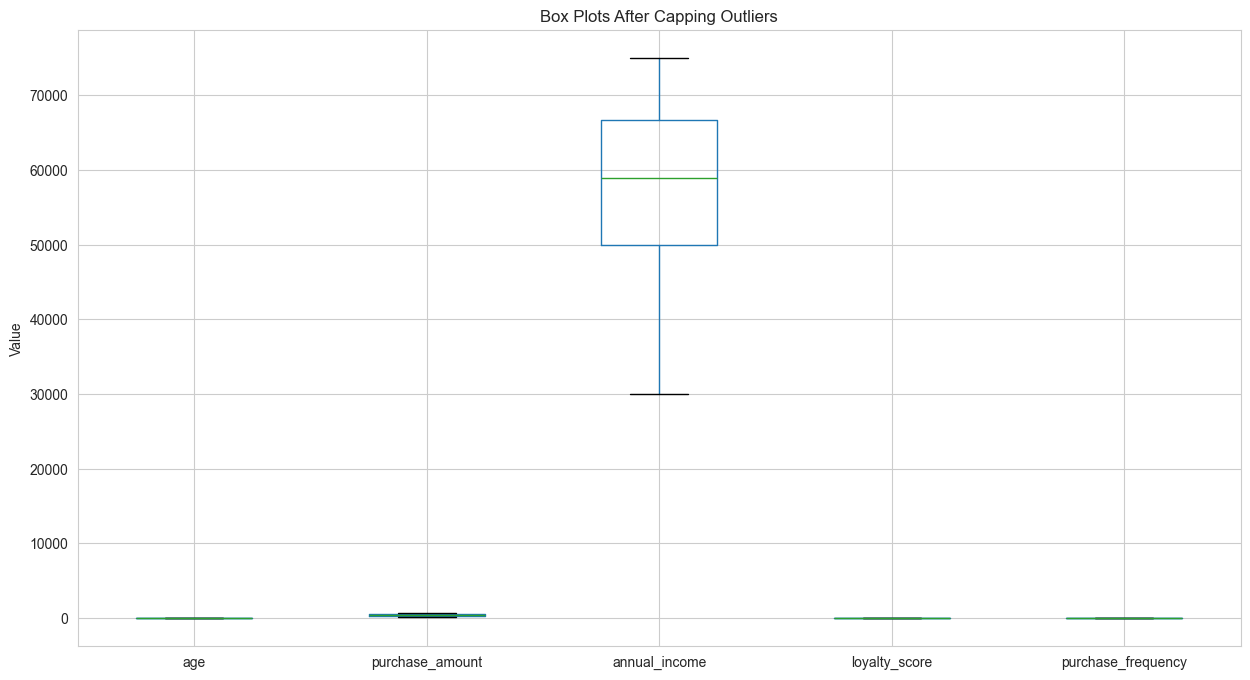

In [4]:
df_processed = df.copy()

for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    df_processed[col] = np.where(
        df_processed[col] > upper_bound, 
        upper_bound, 
        np.where(
            df_processed[col] < lower_bound, 
            lower_bound, 
            df_processed[col]
        )
    )

print("Outliers have been capped.")

# Verify by plotting again
plt.figure(figsize=(15, 8))
df_processed[numerical_cols].boxplot()
plt.title('Box Plots After Capping Outliers')
plt.ylabel('Value')
plt.show()

The new box plots show that the outliers have been successfully handled.

### 4. Encode Categorical Features

The `region` column is categorical. We need to convert it into a numerical format for the model. We will use one-hot encoding, which creates a new binary column for each category.

In [5]:
# Check unique values in the 'region' column
print(f"Unique regions: {df_processed['region'].unique()}")

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

print("\nCategorical features encoded.")
df_processed.head()

Unique regions: ['North' 'South' 'West' 'East']

Categorical features encoded.


,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_North,region_South,region_West
0,1,25.0,45000.0,200.0,4.5,12.0,True,False,False
1,2,34.0,55000.0,350.0,7.0,18.0,False,True,False
2,3,45.0,65000.0,500.0,8.0,22.0,False,False,True
3,4,22.0,30000.0,150.0,3.0,10.0,False,False,False
4,5,29.0,47000.0,220.0,4.8,13.0,True,False,False


We used `drop_first=True` to avoid multicollinearity, which is good practice.

### 5. Standardize Numerical Variables

Clustering algorithms like K-Means are sensitive to the scale of features. We will standardize the numerical columns to have a mean of 0 and a standard deviation of 1.

**Note**: The `user_id` column is an identifier and should not be included in standardization.

In [6]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the numerical columns
df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

print("Numerical features have been standardized.")
df_processed.head()

Numerical features have been standardized.


,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_North,region_South,region_West
0,1,-1.465632,-1.090306,-1.614441,-1.210582,-1.712679,True,False,False
1,2,-0.501151,-0.211563,-0.541153,0.108642,-0.394950,False,True,False
2,3,0.677658,0.667180,0.532134,0.636332,0.483536,False,False,True
3,4,-1.787125,-2.408420,-1.972203,-2.002117,-2.151922,False,False,False
4,5,-1.036974,-0.914557,-1.471336,-1.052275,-1.493057,True,False,False


### 6. Final Processed Data

The data is now preprocessed and ready for exploratory data analysis (EDA) and modeling. Let's review the final DataFrame.

In [7]:
print("Final Processed DataFrame:")
df_processed.head()

Final Processed DataFrame:


,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_North,region_South,region_West
0,1,-1.465632,-1.090306,-1.614441,-1.210582,-1.712679,True,False,False
1,2,-0.501151,-0.211563,-0.541153,0.108642,-0.394950,False,True,False
2,3,0.677658,0.667180,0.532134,0.636332,0.483536,False,False,True
3,4,-1.787125,-2.408420,-1.972203,-2.002117,-2.151922,False,False,False
4,5,-1.036974,-0.914557,-1.471336,-1.052275,-1.493057,True,False,False


In [8]:
df_processed.describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,2.380000e+02,2.380000e+02,2.380000e+02,2.380000e+02,2.380000e+02
mean,119.500000,-2.910837e-16,2.201787e-16,7.463684e-17,4.478211e-17,-1.231508e-16
std,68.848868,1.002107e+00,1.002107e+00,1.002107e+00,1.002107e+00,1.002107e+00
min,1.000000,-1.787125e+00,-2.408420e+00,-1.972203e+00,-2.002117e+00,-2.151922e+00
25%,60.250000,-8.226448e-01,-6.509343e-01,-7.558108e-01,-6.828926e-01,-6.145711e-01
50%,119.500000,3.467085e-02,1.399343e-01,1.028191e-01,1.086420e-01,4.429341e-02
75%,178.750000,8.651954e-01,8.209600e-01,7.289035e-01,7.814464e-01,7.031579e-01
max,238.000000,1.749302e+00,1.545923e+00,1.533869e+00,1.427866e+00,1.801265e+00


The `describe()` output confirms that the numerical columns now have a mean close to 0 and a standard deviation close to 1. The `user_id` remains unchanged, and the `region` column has been replaced by one-hot encoded columns.

The preprocessed data can now be saved or passed directly to the next stage of the analysis.